# libraries

In [2]:
import numpy as np
import matplotlib
from numpy import random
import math
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import statistics as sts

# part 1: 4 independent random walkers

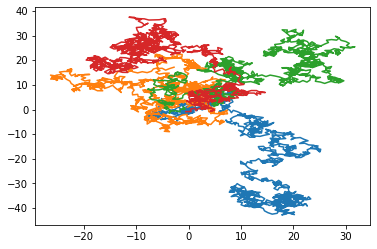

([[-0.7450872232772663,
   0.12417058988555407,
   0.6779757614201575,
   -0.23681344695740136,
   -0.21618286498680214,
   0.5086784894781465,
   1.0042155498362861,
   1.598019465881574,
   1.5818423504664072,
   1.4777552272778467,
   0.7328281028646616,
   1.2545604986598315,
   0.5133301688638106,
   -0.46831905335186486,
   0.49484792014612644,
   0.44779746801984577,
   1.3929706900295082,
   1.3004131273887622,
   1.2957859465292851,
   0.2997238108342267,
   -0.6504186652967113,
   -0.29867227302526766,
   -1.184902289439258,
   -2.1565784585774264,
   -2.2331171318954994,
   -1.2704024551287347,
   -0.6717068057989608,
   -0.2839796250244361,
   0.18931646309467487,
   1.1377453566576572,
   0.2778143857720011,
   0.8569270477535399,
   -0.04100502586030497,
   -0.932856655846671,
   -1.5440964017766854,
   -0.7310680593224504,
   -1.4492673721288227,
   -0.8648435314256546,
   -1.6509722371042628,
   -2.45556605340629,
   -2.402719161083694,
   -2.0593975727687654,
   -2.527

In [3]:
def randwalk(N):
    random.seed(None)
    x,y,L,dx,dy = [], [], [], [], []
    x_,y_=0,0
    l=0

    for i in range(N):
        dx_ = (random.random() -0.5)*2
        dy_ = (random.random() -0.5)*2
        L = math.sqrt((dx_**2)+(dy_**2))
        
        x_+= (1/L)*dx_
        y_+= (1/L)*dy_
        
        dx.append(dx_)
        dy.append(dy_)
        x.append(x_)
        y.append(y_) 
        
    plt.plot(x,y)
    
    return(x,y,dx,dy)
    
def lightrand(N):
    
    x,y,L,dx,dy = [], [], [], [], []
    x_,y_=0,0
    l=0

    for i in range(N):
        dx_ = (random.random() -0.5)*2
        dy_ = (random.random() -0.5)*2
        L = math.sqrt((dx_**2)+(dy_**2))
        
        x_+= (1/L)*dx_
        y_+= (1/L)*dy_
        
        dx.append(dx_)
        dy.append(dy_)
        x.append(x_)
        y.append(y_) 
        
    return(x,y,dx,dy)



def repeater(N,K):
    
    x,y,dx,dy = [], [], [], []
    
    for j in range(K):
        array = randwalk(N)
        x.append(array[0])
        y.append(array[1])
        dx.append(array[2])
        dy.append(array[3])
    plt.show()
    
    
    return(x,y,dx,dy)

def repeater2(N,K):
    
    x,y,dx,dy = [], [], [], []
    
    for j in range(K):
        array = lightrand(N)
        x.append(array[0])
        y.append(array[1])
        dx.append(array[2])
        dy.append(array[3])
    
    
    return(x,y,dx,dy)

repeater(1000,4)

Yes these look random since they do not show a recognizable pattern.

# part 2: root mean square of distance vs $\sqrt{n}$

In [4]:
def root_mean_square(N):
    
    x_sqr_distance_per_trial = []
    sqr_distance_per_trial   = []
    sqr_distance_array       = []
    mean_array               = []
    
    """number of trials in calculating squared distance"""
    
    K = int(math.sqrt(N))
    array = repeater2(N,K)
    x,y,dx,dy = array[0], array[1], array[2], array[3]

    """squared distance for each K trial"""

    for i in range(K):
        for j in range(N):
            R_ = ((dx[i][j])**2)+((dy[i][j])**2)
            #print("R_ value:",R_,"at i:",i,"at j:",j)   # R value checker
            sqr_distance_per_trial.append(R_)
            array = sqr_distance_per_trial.copy()
        sqr_distance_array.append(array)
        sqr_distance_per_trial.clear()
        #print("sqr_distance_array[",i,"] has length:",len(sqr_distance_array[i])) #value checker
    
    """mean square R average each trial then average all the trial averages"""

    #for i in range(K):
    for j in range(K):
        mean_array.append(sts.mean(sqr_distance_array[j]))
    #print(mean_array)  # this code checks that the means are different from each other
    
    R_rms = math.sqrt(sts.mean(mean_array))
    #print("The root mean squared for N =",N," is equal to",R_rms)
    
    return R_rms
    
root_mean_square(100)

0.8152137125279004

Python program that will create an $R_{rms}$ calculator for N = (100,110,...,990,1000)

In [5]:
def R_rms_calc(N):
    
    sqrt_N  = []
    R_rms   = []
    RxsqrtN = []
    N_array = []
    N_array.append(0)
    RxsqrtN.append(0)
    R_rms.append(0)
    sqrt_N.append(0)
    while N < 1010:
        R_rms.append(root_mean_square(N))
        sqrt_N.append(math.sqrt(N))
        RxsqrtN.append(root_mean_square(N)*math.sqrt(N))
        N_array.append(N)
        N+=10
    
    return(R_rms,sqrt_N,RxsqrtN,N_array)

def Rms_printer(N):
    
    array = R_rms_calc(N)
    R_rms,N_array = array[0],array[3]
    for i in range(len(R_rms)):
        print("The root mean squared for N =",N_array[i]," is equal to",R_rms[i])
    


Rms_printer(100)

The root mean squared for N = 0  is equal to 0
The root mean squared for N = 100  is equal to 0.8338597662674567
The root mean squared for N = 110  is equal to 0.8152616500189918
The root mean squared for N = 120  is equal to 0.8031901041703983
The root mean squared for N = 130  is equal to 0.8260578022531601
The root mean squared for N = 140  is equal to 0.8193077024055486
The root mean squared for N = 150  is equal to 0.8140310429030112
The root mean squared for N = 160  is equal to 0.8163654886362894
The root mean squared for N = 170  is equal to 0.8139555039154178
The root mean squared for N = 180  is equal to 0.8145768666348031
The root mean squared for N = 190  is equal to 0.8231550578140847
The root mean squared for N = 200  is equal to 0.8095641455944154
The root mean squared for N = 210  is equal to 0.8145028755788676
The root mean squared for N = 220  is equal to 0.8271584924086048
The root mean squared for N = 230  is equal to 0.8132120048999286
The root mean squared for N =

plotting $R_{rms}$ vs $\sqrt{n}$ and $R_{rms}$ = $\sqrt{n}$

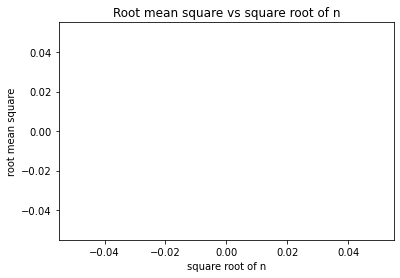

In [10]:
def plotter():
    
    array = R_rms_calc(10000)
    R_rms,sqrt_N = array[2], array[1]
    
    fig, ax = plt.subplots()
    ax.set_title('Root mean square vs square root of n')
    ax.plot(sqrt_N, R_rms,'orange')
    ax.plot(sqrt_N, sqrt_N,'grey')
    ax.set_xlabel("square root of n")
    ax.set_ylabel("root mean square")
    xmin, xmax = plt.xlim()
    ymin, ymax = plt.ylim()
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.show()
    
plotter()

The deivation of the theoretical value only slightly deviates from the theoretical plot. However, we see the deviation get larger and larger N progresses,j ust as in Landau's book

# part 3: radioactive decay

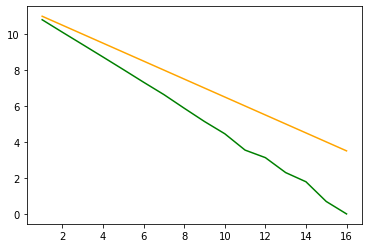

In [12]:
def decay():
    
    random.seed(None)
    N     = 100000
    LN0    = np.log(100000)
    lamda = 0.5
    
    t = 0         # time in integers and in seconds
    
    time          = []
    N_array       = []
    DeltaN_array = []
    LN_N = []
    
    
    """simulating decay as a stochastic algorithm"""
    while N>1:
        DeltaN=0   
        for i in range(N):
            r_i =random.random()         #Generate a random number between 0 and 
            if r_i < lamda:
                DeltaN+=1
        
        
        t += 1
        N -= DeltaN
        LN_N.append(LN0-(lamda*t))
        time.append(t)
        DeltaN_array.append(DeltaN)
        N_array.append(N)
         
    """simulating decay using the equation ln 𝑁=ln 𝑁0―𝜆t"""
        
         
    Nlog = np.log(N_array)    
    plt.plot(time,Nlog, color="green")
    plt.plot(time,LN_N, color="orange")
    plt.show()
    
    
    
decay()

There is a significant discrepancy between the theoretical plot and the experimental plot. We see that the algorithm plot is erratic towards the end while the theoretical plot show a more linear relationship in terms of a log graph. The sudden dip is caused by the spontaineity, while the linearity of the theoretical value shows that it is as predicted.